# Quantum Kernel Machine Learning 

From this tutorial: https://qiskit-community.github.io/qiskit-machine-learning/tutorials/03_quantum_kernel.html

Kernel methods are a collection of pattern analysis algorithms that use kernel functions to operate in a high-dimensional feature space. 
* SVMs are the best-known kernel method for classification tasks
* Kernels draw hyperplane boundaries in a hyperspace, e.g. the "kernel trick"

Kernel functions follow the form $k(\vec{x_i}, \vec{x_j}) = \braket{f(\vec{x_i}), f(\vec{x_j}})$
* $k$ is the kernel function
* $\vec{x_i}$ and $\vec{x_j}$ are $n$ dimensional inputs
* $f$ is a map from $n$-dimension to $m$-dimension space
* $\braket{a,b}$ is an inner product

For finite data we can represent the kernel function as a matrix: $k(\vec{x_i},\vec{x_j}) = K_{ij}$

### Quantum Kernels

The big idea behind quantum kernel machine learning is, leveraging quantum feature maps to perform the kernel trick. The quantum kernel is created by mapping a classical feature vector $\vec{x}$ to a Hilbert space using a quantum feature map $\phi(\vec{x})$:

$K_{ij} = |\braket{\phi(\vec{x_i}) | \phi(\vec{x_j})}|^2$
* $K_{ij}$ is the kernel matrix
* $\phi(\vec{x})$ is the quantum feature map
* $|\braket{a|b}|^2$ is the overlap of two quantum states $a$ and $b$ (i.e. the inner product)

Quantum kernels can be plugged directly into common classical kernel learning algorithms like SVMs or clustering algorithms. They can also be leveraged in new quantum kernel methods like `QSVC` (among others) provided by Qiskit ML (among others)

In [2]:
#set up the global seed for reproducibility
from qiskit_machine_learning.utils import algorithm_globals
algorithm_globals.random_seed = 12345

In [ ]:
#create an ad hoc dataset
#define the dataset dimensions and get our train/test subset
from qiskit_machine_learning.datasets import ad_hoc_data

ad_hoc_dimension=2
train_features, train_labels, test_features, test_labels, adhoc_total =ad_hoc_data(
            training_size=20, test_size=5, 
            n=ad_hoc_dimension, gap=0.3, 
            plot_data=False, one_hot=False,
            include_sample_total=True)

The dataset is 2-dimensional and features are represented by $x$ and $y$ coordinates. There are two class labels $A$ and $B$.

I'm going to copy and paste the code they use for plotting the data to see what the distribution looks like:

In [10]:
import matplotlib.pyplot as plt
import numpy as np


def plot_features(ax, features, labels, class_label, marker, face, edge, label):
    # A train plot
    ax.scatter(
        # x coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 0],
        # y coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 1],
        marker=marker,
        facecolors=face,
        edgecolors=edge,
        label=label,
    )


def plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total):

    plt.figure(figsize=(5, 5))
    plt.ylim(0, 2 * np.pi)
    plt.xlim(0, 2 * np.pi)
    plt.imshow(
        np.asmatrix(adhoc_total).T,
        interpolation="nearest",
        origin="lower",
        cmap="RdBu",
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
    )

    # A train plot
    plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "A train")

    # B train plot
    plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B train")

    # A test plot
    plot_features(plt, test_features, test_labels, 0, "s", "b", "w", "A test")

    # B test plot
    plot_features(plt, test_features, test_labels, 1, "o", "r", "w", "B test")

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
    plt.title("Ad hoc dataset")

    plt.show()

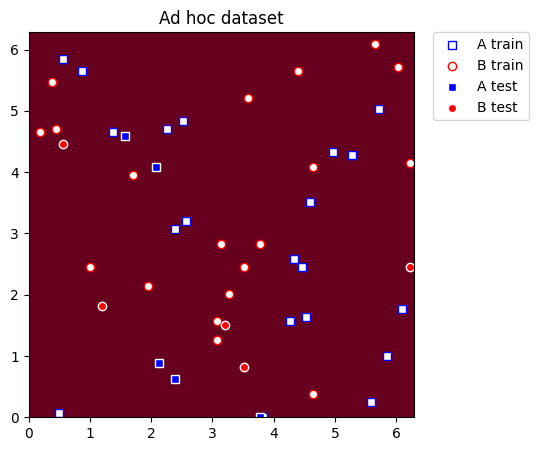

In [11]:
#Now we can plot the dataset
plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total)

The next step is to define a quantum kernel instance to help classify the data. In this case we use the `FidelityQuantumKernel` class and pass two arguments to its constructor:
1. `feature_map` - in this case a two-qubit `zz_feature_map`
2. `fidelity` - in this case, the `ComputeUncompute` fidelity subroutine that leverages the `Sampler` primitive
    * If you do not pass a `Sampler` or `Fidelity` instance, then the instances of the reference `Sampler` and `ComputeUncopute` classes (found in `qiskit.primitives`) will be created by default

###### note: I do not fully understand the computer science behind point #2

Let's define our quantum kernel

In [13]:
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [14]:
adhoc_feature_map = zz_feature_map(
                                feature_dimension=ad_hoc_dimension, 
                                reps=2,
                                entanglement='linear'
                                )

sampler = Sampler()

fidelity = ComputeUncompute(sampler=sampler)

adhoc_kernel = FidelityQuantumKernel(fidelity=fidelity,
                                     feature_map=adhoc_feature_map)

### Classification with SVC

Now we can plug the quantum kernel into a classical kernel method like the standard `SVC` from `scikit-learn`. This algorithm lets us define a custom kernel in two ways:
1. by providing the kernel as a **callable function**
2. by precomputing the **kernel matrix**

#### 1) Kernel as a callable function

We define the SVC model and directly pass the `evaluate` function of the quantum kernel as a callable function. Once the model is created, we train it using the `.fit()` method on the training dataset and evaluate model accuracy using `score`

In [15]:
from sklearn.svm import SVC

In [16]:
adhoc_svc = SVC(kernel=adhoc_kernel.evaluate)
adhoc_svc.fit(train_features, train_labels)

adhoc_score_callable_function = adhoc_svc.score(test_features, test_labels)

print(f"Callable kernel classification test score: {adhoc_score_callable_function}")

Callable kernel classification test score: 1.0


#### 2) Precomputed kernel matrix

Rather than passing a function of the quantum kernel as a callable function, we can instead precompute the training and testing kernel matrices before passing them to the `SVC` algorithm

To extract the train and test matrices we can call `evaluate` on the previously defined kernel and visualize them graphically

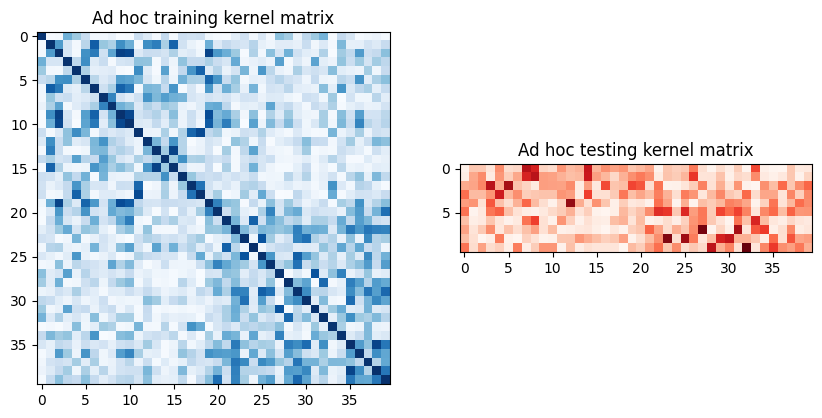

In [17]:
adhoc_matrix_train = adhoc_kernel.evaluate(x_vec=train_features)
adhoc_matrix_test = adhoc_kernel.evaluate(x_vec=test_features, y_vec=train_features)

#copy/paste image code below to plot the kernel matrix

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(
    np.asmatrix(adhoc_matrix_train), interpolation="nearest", origin="upper", cmap="Blues"
)
axs[0].set_title("Ad hoc training kernel matrix")

axs[1].imshow(np.asmatrix(adhoc_matrix_test), interpolation="nearest", origin="upper", cmap="Reds")
axs[1].set_title("Ad hoc testing kernel matrix")

plt.show()

Now that we have precomputed the kernel matrix, we can now use them in the `SVC` classifier. Set the `kernel='precomputed'` parameter of a new `SVC` instance, then train (`.fit()`) on the training matrix and training dataset.

After the model is trained we evaluate by using the test matrix on the test dataset

In [21]:
adhoc_svc = SVC(kernel='precomputed')
adhoc_svc.fit(adhoc_matrix_train, train_labels)

adhoc_score_precomputed_kernel = adhoc_svc.score(adhoc_matrix_test, test_labels)

print(f"Precomputed kernel classification test score: {adhoc_score_precomputed_kernel}")

Precomputed kernel classification test score: 1.0


### Classification with `QSVC`

Instead of using `sklearn` we can just use the alternative training algorithm `QSVC` directly from `qiskit-machine-learning`, which is an extension of `svc` that takes a quantum kernel instead of the `kernel.evaluate` method shown before

In [22]:
from qiskit_machine_learning.algorithms import QSVC

In [23]:
qsvc = QSVC(quantum_kernel=adhoc_kernel)

qsvc.fit(train_features, train_labels)

qsvc_score = qsvc.score(test_features, test_labels)

print(f"QSVC classification test score: {qsvc_score}")

QSVC classification test score: 1.0


In [24]:
#copy/paste
print(f"Classification Model                    | Accuracy Score")
print(f"---------------------------------------------------------")
print(f"SVC using kernel as a callable function | {adhoc_score_callable_function:10.2f}")
print(f"SVC using precomputed kernel matrix     | {adhoc_score_precomputed_kernel:10.2f}")
print(f"QSVC                                    | {qsvc_score:10.2f}")

Classification Model                    | Accuracy Score
---------------------------------------------------------
SVC using kernel as a callable function |       1.00
SVC using precomputed kernel matrix     |       1.00
QSVC                                    |       1.00
